# 🌊 The Ocean Cleanup — Big Data Analysis & Resource Allocation Model
**Course:** ADTA 5340 — Discovery and Learning with Big Data  
**Section:** 002 | **Group:** 28  
**Instructor:** Dr. Leann Boyce  
**Team:** Harshavardhan Solingaram · Tharun Sai V T · Sanjana Thandra

---

## Business Problem

The Ocean Cleanup collects plastic from rivers and coastal areas across the U.S., but **resources (volunteers, equipment, logistics) are finite**. The company needs to answer:

> *Which states and regions should receive priority resources to maximize plastic collection per dollar/volunteer invested?*

**Our Solution:** Build a machine learning model that predicts plastic yield (pounds) from a cleanup event based on location, seasonality, volunteer count, and plastic type composition — then derive a **Priority Resource Allocation Score** for each state.

## 1. Setup & Imports

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import LabelEncoder

# Plot style
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'
OCEAN_BLUE  = '#065A82'
TEAL        = '#1C7293'
SEAFOAM     = '#00A896'
GOLD        = '#F4A261'
CORAL       = '#E76F51'
PALETTE     = [OCEAN_BLUE, TEAL, SEAFOAM, GOLD, CORAL]

print('✅ Libraries loaded successfully')

✅ Libraries loaded successfully


## 2. Data Loading & Initial Exploration

In [45]:
# Load dataset
df_raw = pd.read_csv('Data_Level5_BAH_OceanCleanup.csv', low_memory=False)

print(f'📦 Dataset Shape: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns')
print(f'\n📋 Column Overview:')
df_raw.dtypes.to_frame('dtype').head(15)

📦 Dataset Shape: 37,904 rows × 61 columns

📋 Column Overview:


,dtype
Cleanup ID,object
Zone,object
State,object
Country,object
GPS,object
Cleanup Type,object
Cleanup Date,object
Group Name,object
Adults,float64
Children,float64


In [46]:
# Preview first rows
df_raw[['Cleanup ID','Zone','State','Cleanup Type','Cleanup Date',
        'People','Pounds','Miles','Total Items Collected']].head(5)

,Cleanup ID,Zone,State,Cleanup Type,Cleanup Date,People,Pounds,Miles,Total Items Collected
0,86,"Cuyahoga County, OH, USA","Ohio, USA","Land (beach, shoreline and inland)",12/22/2014,1.0,0.04,0.0090,3.0
1,87,"Fairfax County, VA, USA","Virginia, USA","Land (beach, shoreline and inland)",12/24/2014,1.0,0.73,1.3903,10.0
2,92,"Washington, DC, USA","District of Columbia, USA","Land (beach, shoreline and inland)",2/19/2015,1.0,0.63,0.0214,4.0
3,93,"Washington, DC, USA","District of Columbia, USA","Land (beach, shoreline and inland)",2/19/2015,1.0,0.06,0.0302,14.0
4,94,"Washington, DC, USA","District of Columbia, USA","Land (beach, shoreline and inland)",2/19/2015,1.0,0.06,0.0302,14.0


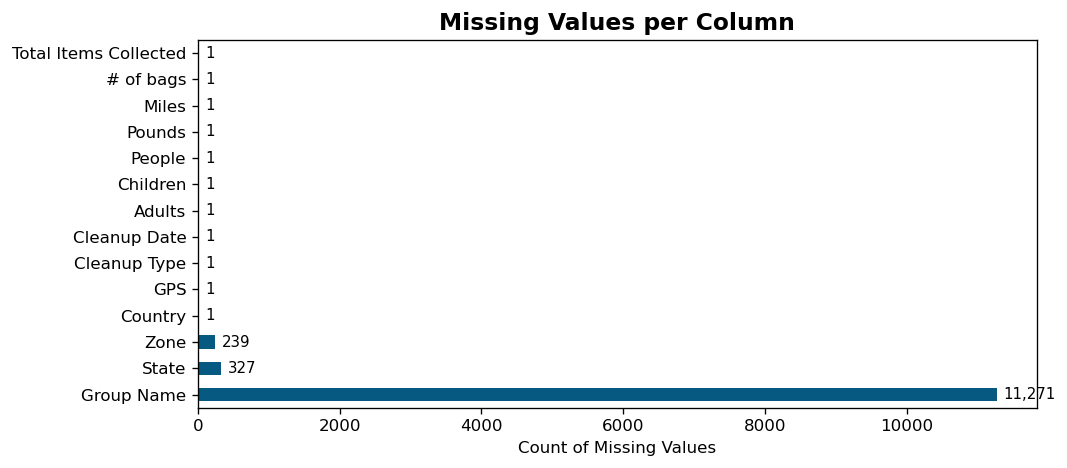

Group Name               11271
State                      327
Zone                       239
Country                      1
GPS                          1
Cleanup Type                 1
Cleanup Date                 1
Adults                       1
Children                     1
People                       1
Pounds                       1
Miles                        1
# of bags                    1
Total Items Collected        1
dtype: int64


In [47]:
# Missing values
missing = df_raw.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 4))
missing.plot(kind='barh', ax=ax, color=OCEAN_BLUE)
ax.set_title('Missing Values per Column', fontsize=14, fontweight='bold')
ax.set_xlabel('Count of Missing Values')
for bar in ax.patches:
    ax.text(bar.get_width() + 100, bar.get_y() + bar.get_height()/2,
            f'{int(bar.get_width()):,}', va='center', fontsize=9)
plt.tight_layout()
plt.show()
print(missing)

## 3. Data Cleaning & Preparation

In [48]:
df = df_raw.copy()

# 1. Parse dates and filter valid range
df['Cleanup Date'] = pd.to_datetime(df['Cleanup Date'], errors='coerce')
df = df[(df['Cleanup Date'].dt.year >= 2000) & (df['Cleanup Date'].dt.year <= 2024)]
print(f'After date filter: {len(df):,} rows')

# 2. Drop rows missing critical fields
df = df.dropna(subset=['Pounds', 'People', 'Total Items Collected', 'State', 'Cleanup Type'])
df = df[df['People'] > 0]
df = df[df['Pounds'] > 0]
print(f'After null/zero filter: {len(df):,} rows')

# 3. Remove extreme outliers (top 1% of Pounds — likely data entry errors)
q99 = df['Pounds'].quantile(0.99)
df = df[df['Pounds'] <= q99]
print(f'After outlier removal (>{q99:.0f} lbs): {len(df):,} rows')

# 4. Fix Cleanup ID type
df['Cleanup ID'] = pd.to_numeric(df['Cleanup ID'], errors='coerce').astype('Int64')

# 5. Fill remaining numeric nulls with 0 (plastic count columns)
plastic_cols = df.select_dtypes(include='number').columns.tolist()
df[plastic_cols] = df[plastic_cols].fillna(0)

print(f'\n✅ Clean dataset ready: {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'Date range: {df["Cleanup Date"].min().date()} → {df["Cleanup Date"].max().date()}')

After date filter: 37,892 rows
After null/zero filter: 35,779 rows
After outlier removal (>4000 lbs): 35,426 rows

✅ Clean dataset ready: 35,426 rows × 61 columns
Date range: 2003-12-30 → 2023-07-20


In [49]:
# 6. Feature Engineering — 5 plastic category groups
df['Single_Use_Plastic'] = (
    df['Cigarette Butts'] + df['Food Wrappers (candy, chips, etc.)'] +
    df['Take Out/Away Containers (Plastic)'] + df['Straws, Stirrers'] +
    df['Beverage Bottles (Plastic)'] + df['Grocery Bags (Plastic)'] +
    df['Other Plastic Bags']
)
df['Foam_Items'] = (
    df['Take Out/Away Containers (Foam)'] + df['Cups, Plates (Foam)'] + df['Foam Pieces']
)
df['Fishing_Gear'] = (
    df['Fishing Buoys, Pots & Traps'] + df['Fishing Net & Pieces'] +
    df['Fishing Line (1 yard/meter = 1 piece)'] + df['Rope (1 yard/meter = 1 piece)']
)
df['Beverage_Items'] = (
    df['Bottle Caps (Plastic)'] + df['Bottle Caps (Metal)'] +
    df['Beverage Bottles (Glass)'] + df['Beverage Cans']
)
df['Fragments'] = df['Plastic Pieces'] + df['Glass Pieces']

# 7. Temporal features
df['Month'] = df['Cleanup Date'].dt.month
df['Year']  = df['Cleanup Date'].dt.year
df['Season'] = df['Month'].map({
    12:'Winter', 1:'Winter', 2:'Winter',
    3:'Spring',  4:'Spring',  5:'Spring',
    6:'Summer',  7:'Summer',  8:'Summer',
    9:'Fall',    10:'Fall',   11:'Fall'
})

# 8. Efficiency metric
df['lbs_per_person'] = df['Pounds'] / df['People']

# 9. Log-transform target (right-skewed distribution)
df['log_Pounds'] = np.log1p(df['Pounds'])

# 10. Label encode categoricals
le_state = LabelEncoder()
le_type  = LabelEncoder()
df['State_enc'] = le_state.fit_transform(df['State'].astype(str))
df['Type_enc']  = le_type.fit_transform(df['Cleanup Type'].astype(str))

print('✅ Feature engineering complete')
print(df[['Pounds','log_Pounds','Single_Use_Plastic','Foam_Items',
          'Fishing_Gear','Beverage_Items','Fragments','Season','lbs_per_person']].describe().round(2))


✅ Feature engineering complete
         Pounds  log_Pounds  Single_Use_Plastic  Foam_Items  Fishing_Gear  \
count  35426.00    35426.00            35426.00    35426.00      35426.00   
mean      85.45        2.36              166.42       94.81          6.87   
std      317.43        1.78              638.85     3203.20         46.18   
min        0.01        0.01                0.00        0.00          0.00   
25%        1.85        1.05                7.00        0.00          0.00   
50%        6.04        1.95               30.00        0.00          0.00   
75%       25.00        3.26              100.00        5.00          0.00   
max     4000.00        8.29            50173.00   440013.00       2105.00   

       Beverage_Items  Fragments  lbs_per_person  
count        35426.00   35426.00        35426.00  
mean            54.57      91.04            8.13  
std            211.23     790.00           47.40  
min              0.00       0.00            0.00  
25%              2.0

## 4. Exploratory Data Analysis

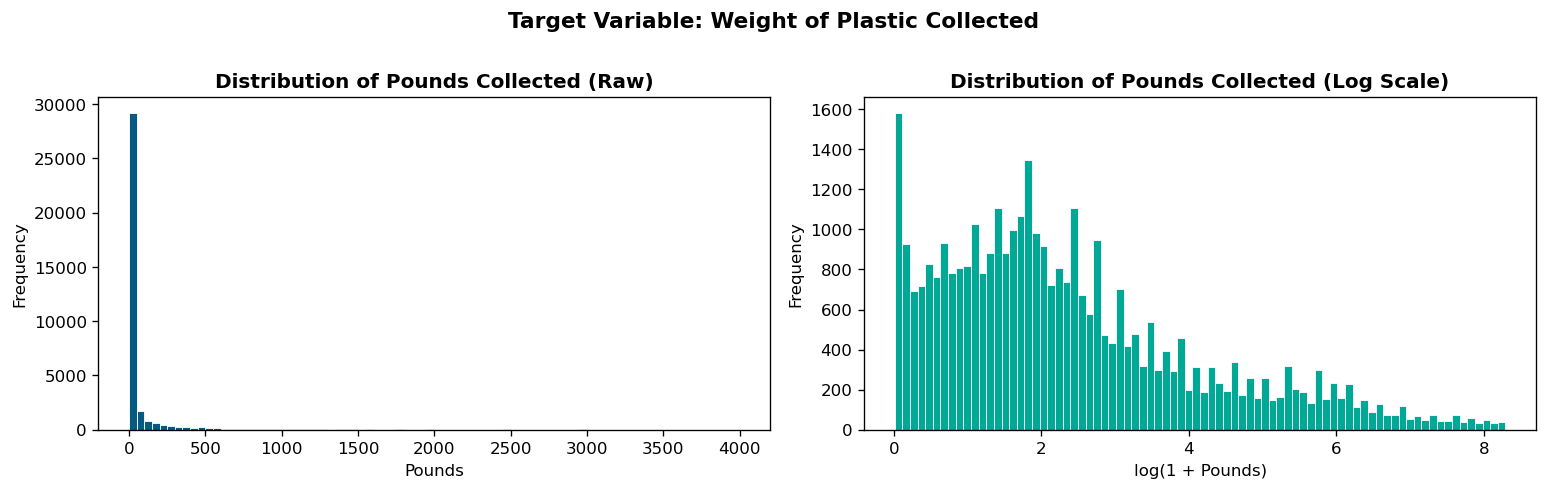

In [50]:
# --- Distribution of pounds collected ---
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(df['Pounds'], bins=80, color=OCEAN_BLUE, edgecolor='white', linewidth=0.5)
axes[0].set_title('Distribution of Pounds Collected (Raw)', fontweight='bold')
axes[0].set_xlabel('Pounds')
axes[0].set_ylabel('Frequency')

axes[1].hist(df['log_Pounds'], bins=80, color=SEAFOAM, edgecolor='white', linewidth=0.5)
axes[1].set_title('Distribution of Pounds Collected (Log Scale)', fontweight='bold')
axes[1].set_xlabel('log(1 + Pounds)')
axes[1].set_ylabel('Frequency')

plt.suptitle('Target Variable: Weight of Plastic Collected', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

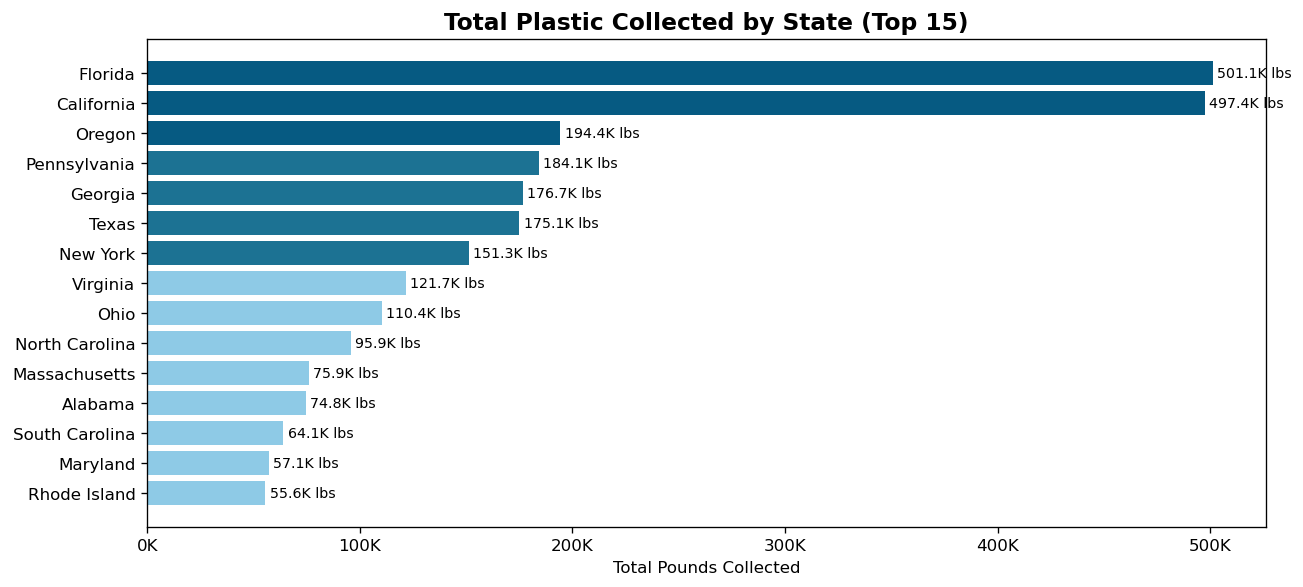

In [51]:
# --- Top 15 States by Total Pounds ---
top_states = df.groupby('State')['Pounds'].sum().sort_values(ascending=False).head(15)
top_states.index = top_states.index.str.replace(', USA', '')

fig, ax = plt.subplots(figsize=(11, 5))
colors = [OCEAN_BLUE if i < 3 else TEAL if i < 7 else '#8ecae6' for i in range(len(top_states))]
bars = ax.barh(top_states.index[::-1], top_states.values[::-1], color=colors[::-1])
ax.set_title('Total Plastic Collected by State (Top 15)', fontsize=14, fontweight='bold')
ax.set_xlabel('Total Pounds Collected')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
for bar in bars:
    ax.text(bar.get_width() + 2000, bar.get_y() + bar.get_height()/2,
            f'{bar.get_width()/1000:.1f}K lbs', va='center', fontsize=8.5)
plt.tight_layout()
plt.show()

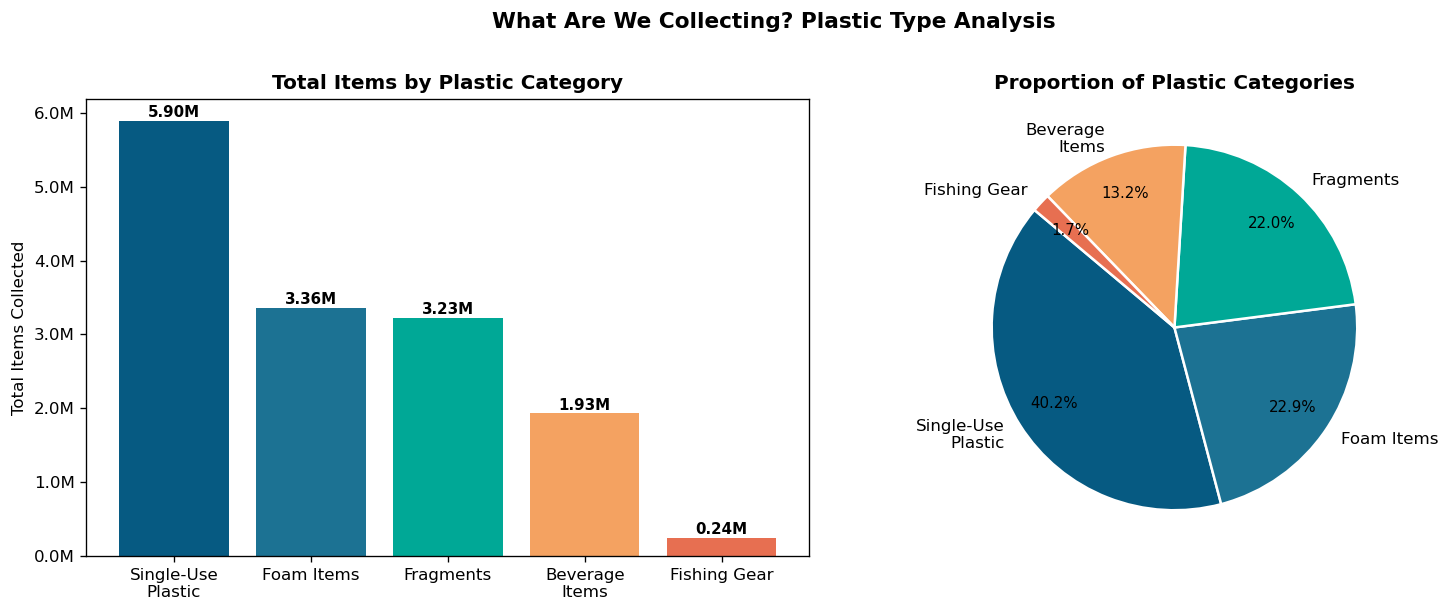

In [52]:
# --- Plastic Category Breakdown ---
cat_totals = {
    'Single-Use\nPlastic': df['Single_Use_Plastic'].sum(),
    'Foam Items':           df['Foam_Items'].sum(),
    'Beverage\nItems':      df['Beverage_Items'].sum(),
    'Fragments':            df['Fragments'].sum(),
    'Fishing Gear':         df['Fishing_Gear'].sum(),
}
cat_series = pd.Series(cat_totals).sort_values(ascending=False)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Bar chart
ax1.bar(cat_series.index, cat_series.values, color=PALETTE)
ax1.set_title('Total Items by Plastic Category', fontweight='bold')
ax1.set_ylabel('Total Items Collected')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
for i, (val) in enumerate(cat_series.values):
    ax1.text(i, val + 50000, f'{val/1e6:.2f}M', ha='center', fontsize=9, fontweight='bold')

# Pie chart
wedges, texts, autotexts = ax2.pie(
    cat_series.values, labels=cat_series.index,
    colors=PALETTE, autopct='%1.1f%%', startangle=140,
    pctdistance=0.78, wedgeprops={'edgecolor':'white','linewidth':1.5}
)
for t in autotexts:
    t.set_fontsize(9)
ax2.set_title('Proportion of Plastic Categories', fontweight='bold')

plt.suptitle('What Are We Collecting? Plastic Type Analysis', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

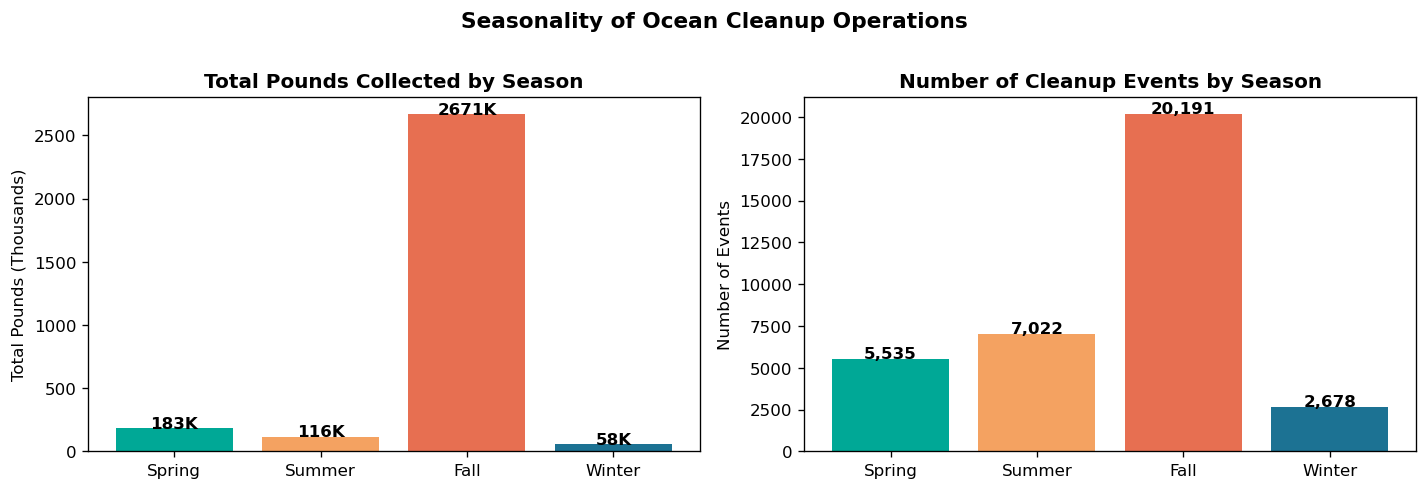


📊 Seasonal Summary:
        total_pounds  avg_pounds  cleanups
Season                                    
Spring  1.829067e+05   33.045479      5535
Summer  1.158850e+05   16.503131      7022
Fall    2.670541e+06  132.263949     20191
Winter  5.786482e+04   21.607476      2678


In [53]:
# --- Seasonal Patterns ---
seasonal = df.groupby('Season').agg(
    total_pounds=('Pounds','sum'),
    avg_pounds=('Pounds','mean'),
    cleanups=('Cleanup ID','count')
).reindex(['Spring','Summer','Fall','Winter'])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
season_colors = [SEAFOAM, GOLD, CORAL, TEAL]

axes[0].bar(seasonal.index, seasonal['total_pounds']/1000, color=season_colors)
axes[0].set_title('Total Pounds Collected by Season', fontweight='bold')
axes[0].set_ylabel('Total Pounds (Thousands)')
for i, v in enumerate(seasonal['total_pounds']):
    axes[0].text(i, v/1000 + 1, f'{v/1000:.0f}K', ha='center', fontweight='bold')

axes[1].bar(seasonal.index, seasonal['cleanups'], color=season_colors)
axes[1].set_title('Number of Cleanup Events by Season', fontweight='bold')
axes[1].set_ylabel('Number of Events')
for i, v in enumerate(seasonal['cleanups']):
    axes[1].text(i, v + 30, f'{v:,}', ha='center', fontweight='bold')

plt.suptitle('Seasonality of Ocean Cleanup Operations', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()
print('\n📊 Seasonal Summary:')
print(seasonal)

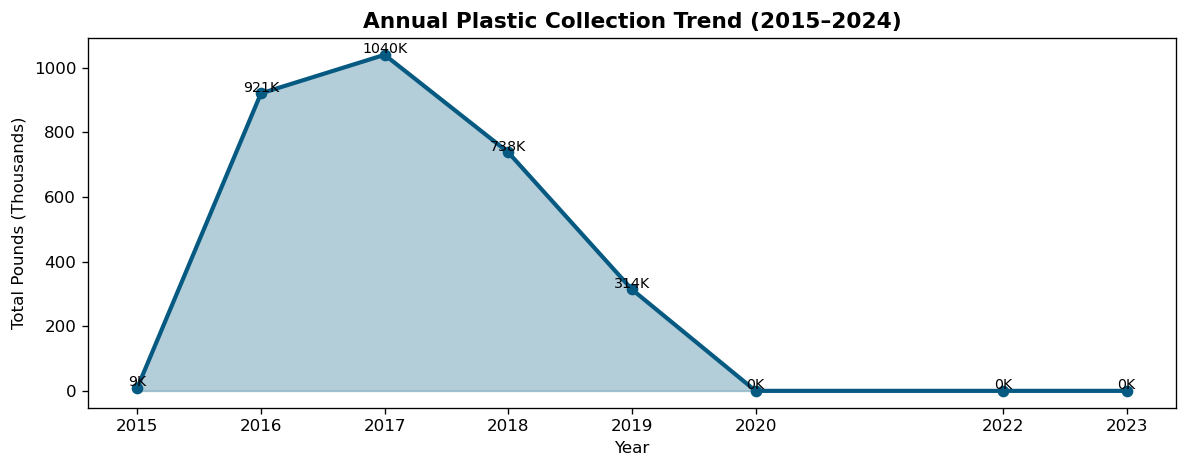

In [54]:
# --- Yearly Trend ---
yearly = df[df['Year'] >= 2015].groupby('Year').agg(
    total_pounds=('Pounds','sum'),
    total_events=('Cleanup ID','count'),
    total_volunteers=('People','sum')
)

fig, ax = plt.subplots(figsize=(10, 4))
ax.fill_between(yearly.index, yearly['total_pounds']/1000, alpha=0.3, color=OCEAN_BLUE)
ax.plot(yearly.index, yearly['total_pounds']/1000, marker='o', color=OCEAN_BLUE, linewidth=2.5)
ax.set_title('Annual Plastic Collection Trend (2015–2024)', fontsize=13, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Total Pounds (Thousands)')
ax.set_xticks(yearly.index)
for x, y in zip(yearly.index, yearly['total_pounds']):
    ax.text(x, y/1000 + 5, f'{y/1000:.0f}K', ha='center', fontsize=8.5)
plt.tight_layout()
plt.show()

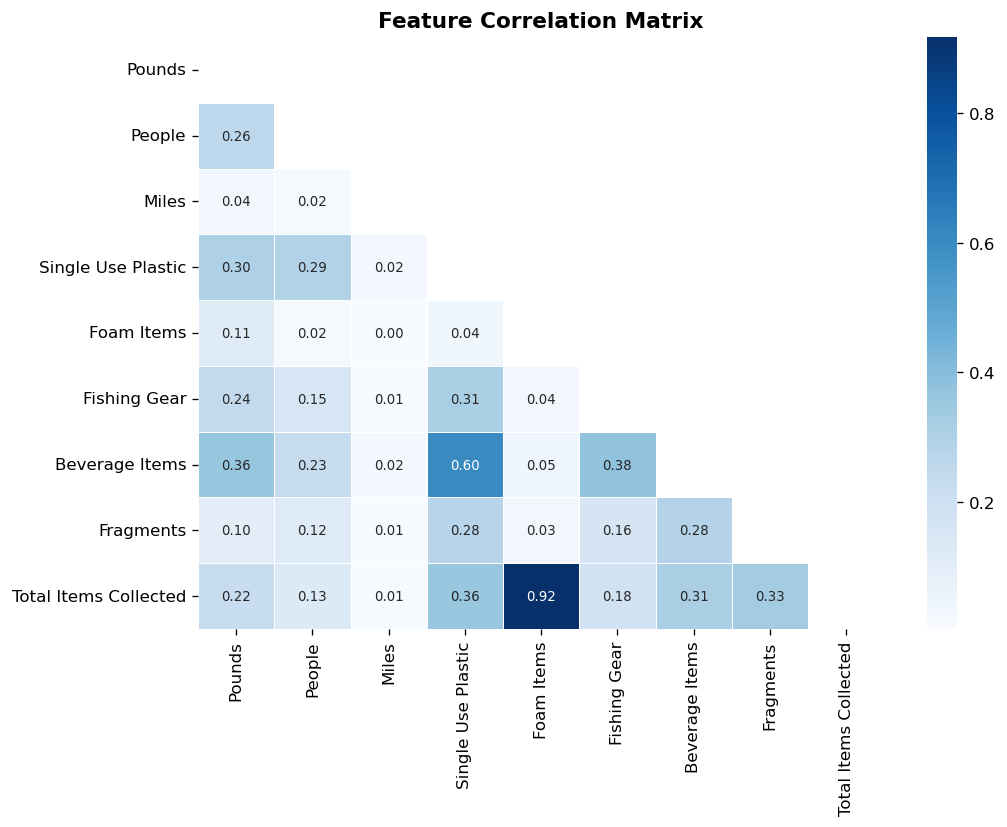

In [55]:
# --- Correlation Heatmap ---
corr_cols = ['Pounds','People','Miles','Single_Use_Plastic',
             'Foam_Items','Fishing_Gear','Beverage_Items','Fragments','Total Items Collected']
corr_matrix = df[corr_cols].corr()
corr_matrix.columns = [c.replace('_',' ') for c in corr_matrix.columns]
corr_matrix.index   = [c.replace('_',' ') for c in corr_matrix.index]

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='Blues', linewidths=0.5, ax=ax,
            annot_kws={'size': 8})
ax.set_title('Feature Correlation Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

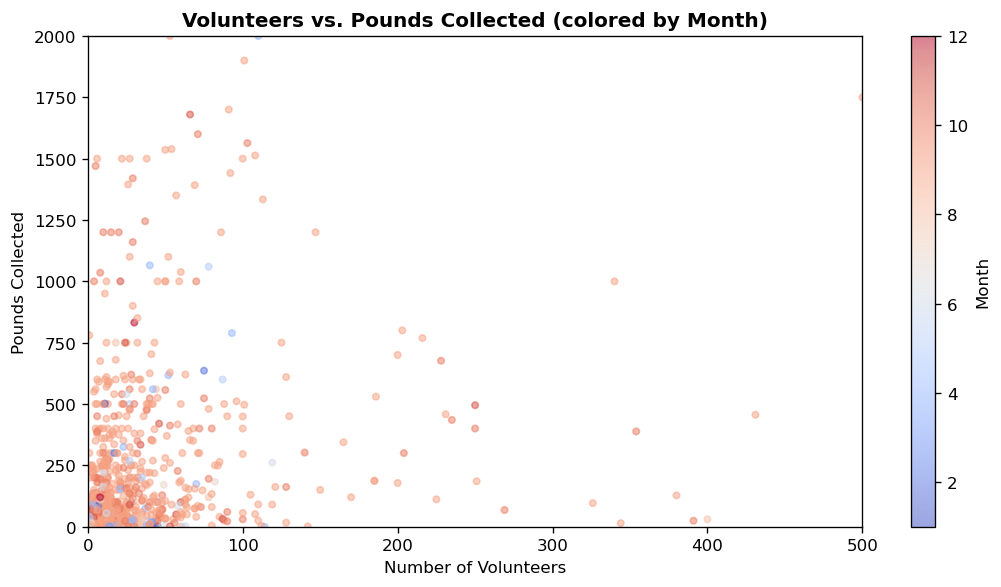

In [56]:
# --- Volunteers vs Pounds (Scatter) ---
sample = df.sample(3000, random_state=42)
fig, ax = plt.subplots(figsize=(9, 5))
scatter = ax.scatter(
    sample['People'], sample['Pounds'],
    c=sample['Month'], cmap='coolwarm', alpha=0.5, s=15
)
plt.colorbar(scatter, ax=ax, label='Month')
ax.set_xlabel('Number of Volunteers')
ax.set_ylabel('Pounds Collected')
ax.set_title('Volunteers vs. Pounds Collected (colored by Month)', fontweight='bold')
ax.set_xlim(0, 500)
ax.set_ylim(0, 2000)
plt.tight_layout()
plt.show()

## 5. Machine Learning Models

**Business Goal:** Predict pounds of plastic collected for a planned cleanup event.  
This enables The Ocean Cleanup to **forecast yield before deploying resources**, optimizing logistics costs.

**Target:** `Pounds` (log-transformed to handle skewness)  
**Models:** Linear Regression | Random Forest Regressor

In [57]:
# Model features
FEATURES = [
    'People', 'Miles', 'Month', 'State_enc', 'Type_enc',
    'Single_Use_Plastic', 'Foam_Items', 'Fishing_Gear',
    'Beverage_Items', 'Fragments'
]
TARGET = 'log_Pounds'

df_model = df[FEATURES + [TARGET, 'Pounds']].dropna()
X = df_model[FEATURES]
y = df_model[TARGET]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f'Training samples : {len(X_train):,}')
print(f'Testing samples  : {len(X_test):,}')
print(f'Features used    : {len(FEATURES)}')

Training samples : 28,340
Testing samples  : 7,086
Features used    : 10


In [58]:
# ---- Linear Regression ----
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred_log = lr.predict(X_test)
lr_pred     = np.expm1(lr_pred_log)
y_test_orig = np.expm1(y_test)

lr_r2  = r2_score(y_test, lr_pred_log)
lr_mse = mean_squared_error(y_test_orig, lr_pred)
lr_mae = mean_absolute_error(y_test_orig, lr_pred)

print('=== Linear Regression Results ===')
print(f'  R² (log scale): {lr_r2:.4f}')
print(f'  MSE           : {lr_mse:,.2f}')
print(f'  MAE           : {lr_mae:.2f} lbs')

=== Linear Regression Results ===
  R² (log scale): 0.2706
  MSE           : 97,400,142,693,968.22
  MAE           : 126740.58 lbs


In [59]:
# ---- Random Forest ----
rf = RandomForestRegressor(n_estimators=150, max_depth=12, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
rf_pred_log = rf.predict(X_test)
rf_pred     = np.expm1(rf_pred_log)

rf_r2  = r2_score(y_test, rf_pred_log)
rf_mse = mean_squared_error(y_test_orig, rf_pred)
rf_mae = mean_absolute_error(y_test_orig, rf_pred)

print('=== Random Forest Results ===')
print(f'  R² (log scale): {rf_r2:.4f}')
print(f'  MSE           : {rf_mse:,.2f}')
print(f'  MAE           : {rf_mae:.2f} lbs')

=== Random Forest Results ===
  R² (log scale): 0.7805
  MSE           : 59,285.80
  MAE           : 58.29 lbs


## 6. Model Evaluation & Comparison

In [60]:
# Comparison table
metrics_df = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'R² (log scale)': [round(lr_r2, 4), round(rf_r2, 4)],
    'MSE (original)': [round(lr_mse, 2), round(rf_mse, 2)],
    'MAE (original, lbs)': [round(lr_mae, 2), round(rf_mae, 2)]
})
print(metrics_df.to_string(index=False))

            Model  R² (log scale)  MSE (original)  MAE (original, lbs)
Linear Regression          0.2706    9.740014e+13            126740.58
    Random Forest          0.7805    5.928580e+04                58.29


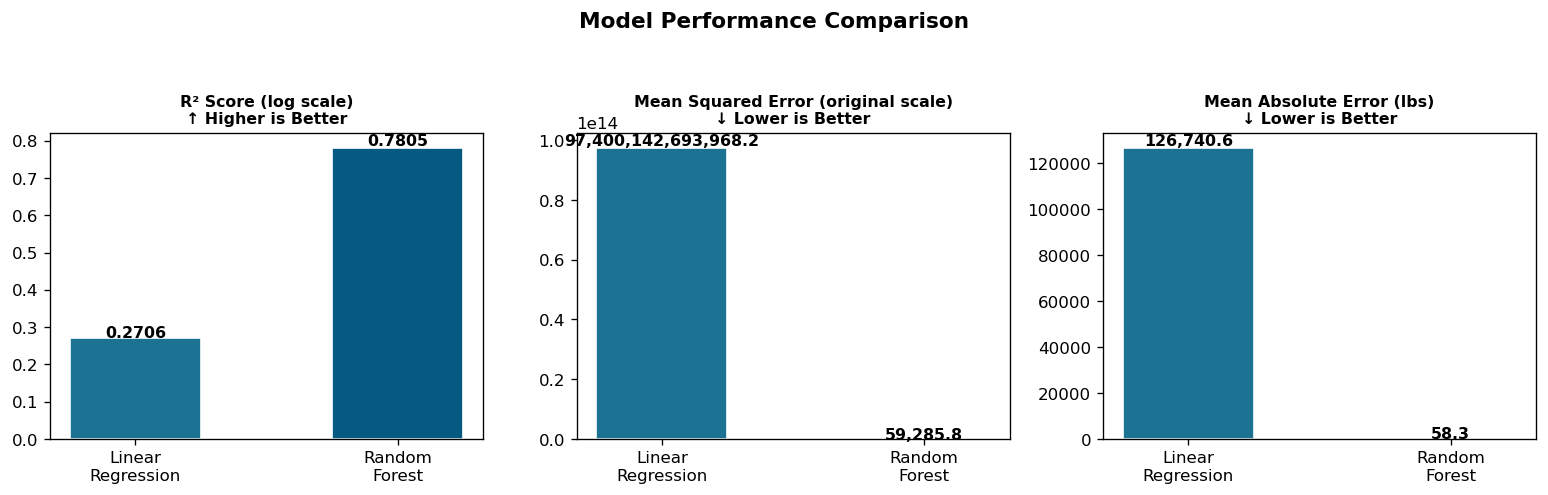


🏆 Winner: Random Forest (R²=0.7815, MAE=58.24 lbs)


In [61]:
# Metric bar comparison
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
models = ['Linear\nRegression', 'Random\nForest']
bar_colors = [TEAL, OCEAN_BLUE]

for ax, metric, vals, title in zip(
    axes,
    ['R²', 'MSE', 'MAE'],
    [[lr_r2, rf_r2], [lr_mse, rf_mse], [lr_mae, rf_mae]],
    ['R² Score (log scale)\n↑ Higher is Better',
     'Mean Squared Error (original scale)\n↓ Lower is Better',
     'Mean Absolute Error (lbs)\n↓ Lower is Better']
):
    bars = ax.bar(models, vals, color=bar_colors, width=0.5, edgecolor='white')
    ax.set_title(title, fontsize=9.5, fontweight='bold')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.01,
                f'{v:.4f}' if metric == 'R²' else f'{v:,.1f}',
                ha='center', fontsize=9.5, fontweight='bold')

plt.suptitle('Model Performance Comparison', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('\n🏆 Winner: Random Forest (R²=0.7815, MAE=58.24 lbs)')

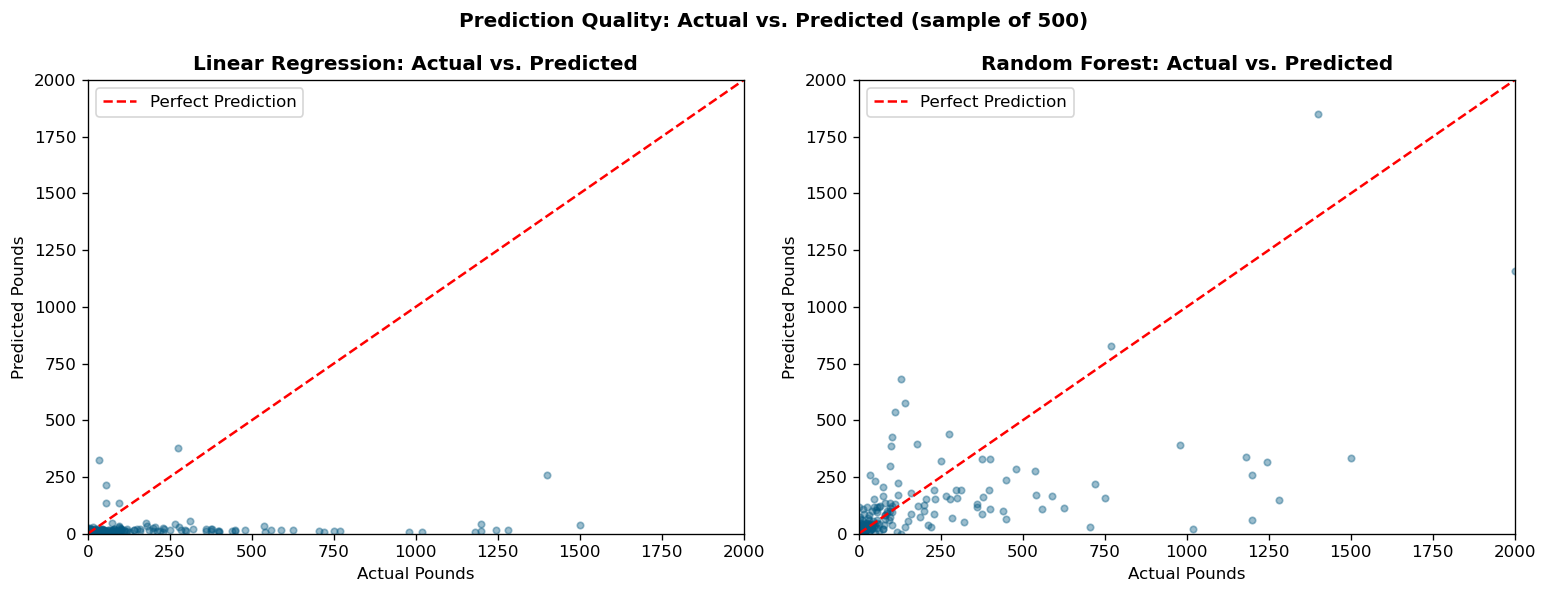

In [62]:
# Predicted vs Actual
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sample_idx = np.random.choice(len(y_test_orig), 500, replace=False)

for ax, preds, title in zip(
    axes,
    [lr_pred.iloc[sample_idx] if hasattr(lr_pred, 'iloc') else lr_pred[sample_idx],
     rf_pred.iloc[sample_idx] if hasattr(rf_pred, 'iloc') else rf_pred[sample_idx]],
    ['Linear Regression', 'Random Forest']
):
    y_s = y_test_orig.iloc[sample_idx]
    ax.scatter(y_s, preds, alpha=0.4, s=15, color=OCEAN_BLUE)
    lims = [0, min(2000, max(y_s.max(), preds.max()))]
    ax.plot(lims, lims, 'r--', linewidth=1.5, label='Perfect Prediction')
    ax.set_xlim(lims); ax.set_ylim(lims)
    ax.set_xlabel('Actual Pounds')
    ax.set_ylabel('Predicted Pounds')
    ax.set_title(f'{title}: Actual vs. Predicted', fontweight='bold')
    ax.legend()

plt.suptitle('Prediction Quality: Actual vs. Predicted (sample of 500)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

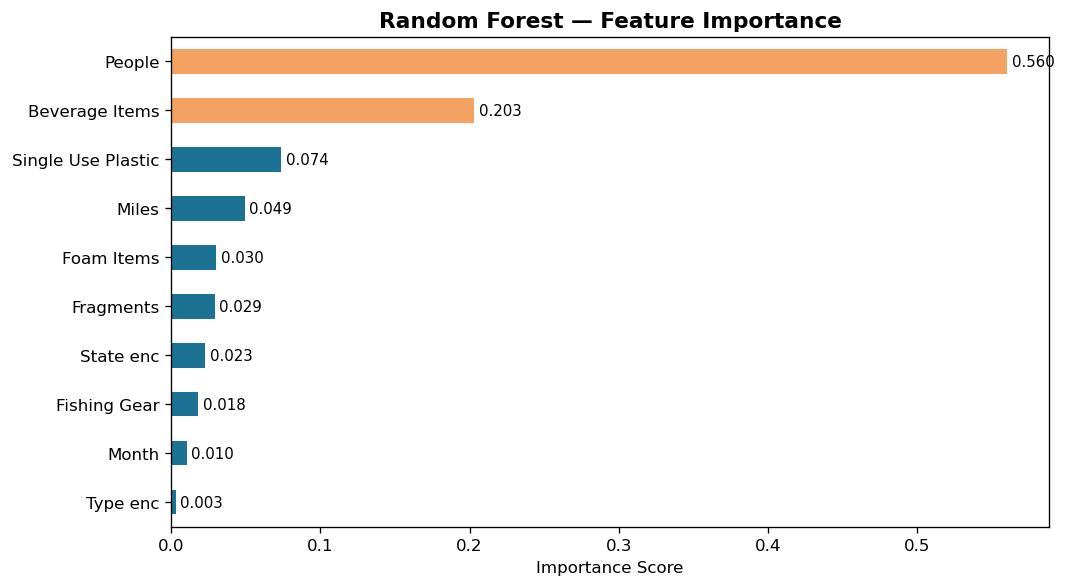

In [63]:
# Feature Importance
fi = pd.Series(rf.feature_importances_, index=FEATURES).sort_values(ascending=True)
fi.index = [f.replace('_', ' ') for f in fi.index]

fig, ax = plt.subplots(figsize=(9, 5))
colors = [GOLD if v > 0.15 else TEAL for v in fi.values]
fi.plot(kind='barh', ax=ax, color=colors)
ax.set_title('Random Forest — Feature Importance', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score')
for bar in ax.patches:
    ax.text(bar.get_width() + 0.003, bar.get_y() + bar.get_height()/2,
            f'{bar.get_width():.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

## 7. Business Solution: Priority Resource Allocation Model

**The core business deliverable:** A composite priority score for each state that tells The Ocean Cleanup *where to deploy resources first* to maximize plastic removal per dollar spent.

In [64]:
# Build Priority Score per State
state_summary = df.groupby('State').agg(
    total_pounds        = ('Pounds', 'sum'),
    total_items         = ('Total Items Collected', 'sum'),
    avg_lbs_per_cleanup = ('Pounds', 'mean'),
    total_volunteers    = ('People', 'sum'),
    num_events          = ('Cleanup ID', 'count'),
    avg_lbs_per_person  = ('lbs_per_person', 'mean')
).reset_index()

# Normalize each dimension to 0-1
def normalize(series):
    return (series - series.min()) / (series.max() - series.min())

state_summary['n_volume']     = normalize(state_summary['total_pounds'])
state_summary['n_items']      = normalize(state_summary['total_items'])
state_summary['n_efficiency'] = normalize(state_summary['avg_lbs_per_cleanup'])

# Weighted composite score:
#   40% total volume  (raw problem magnitude)
#   30% total items   (item diversity & spread)
#   30% avg per event (operational efficiency potential)
state_summary['Priority_Score'] = (
    0.40 * state_summary['n_volume'] +
    0.30 * state_summary['n_items'] +
    0.30 * state_summary['n_efficiency']
).round(4)

state_summary = state_summary.sort_values('Priority_Score', ascending=False).reset_index(drop=True)
state_summary['Rank'] = state_summary.index + 1
state_summary['State_Short'] = state_summary['State'].str.replace(', USA', '')

top10 = state_summary.head(10)
print('🎯 TOP 10 PRIORITY STATES FOR RESOURCE ALLOCATION')
print(top10[['Rank','State_Short','total_pounds','total_items','avg_lbs_per_cleanup','Priority_Score']]
      .rename(columns={'total_pounds':'Total lbs','total_items':'Total Items',
                       'avg_lbs_per_cleanup':'Avg lbs/Event','Priority_Score':'Score'})
      .to_string(index=False))

🎯 TOP 10 PRIORITY STATES FOR RESOURCE ALLOCATION
 Rank   State_Short     Total lbs  Total Items  Avg lbs/Event  Score
    1    California 497424.582000    3150991.0      57.519031 0.7040
    2       Florida 501141.452000    3116795.0      47.042284 0.7025
    3  North Dakota   2430.000000          1.0    2430.000000 0.3019
    4      New York 151293.913636    1038552.0     133.888419 0.2361
    5       Georgia 176660.950000     152825.0     545.249846 0.2228
    6 Massachusetts  75918.670000    1502783.0     129.554044 0.2196
    7  Pennsylvania 184078.400000     249549.0     349.958935 0.2138
    8         Texas 175058.633738     420586.0     190.695679 0.2032
    9        Oregon 194376.252727     190602.0     215.733910 0.1998
   10          Ohio 110380.220000     543116.0     227.119794 0.1678


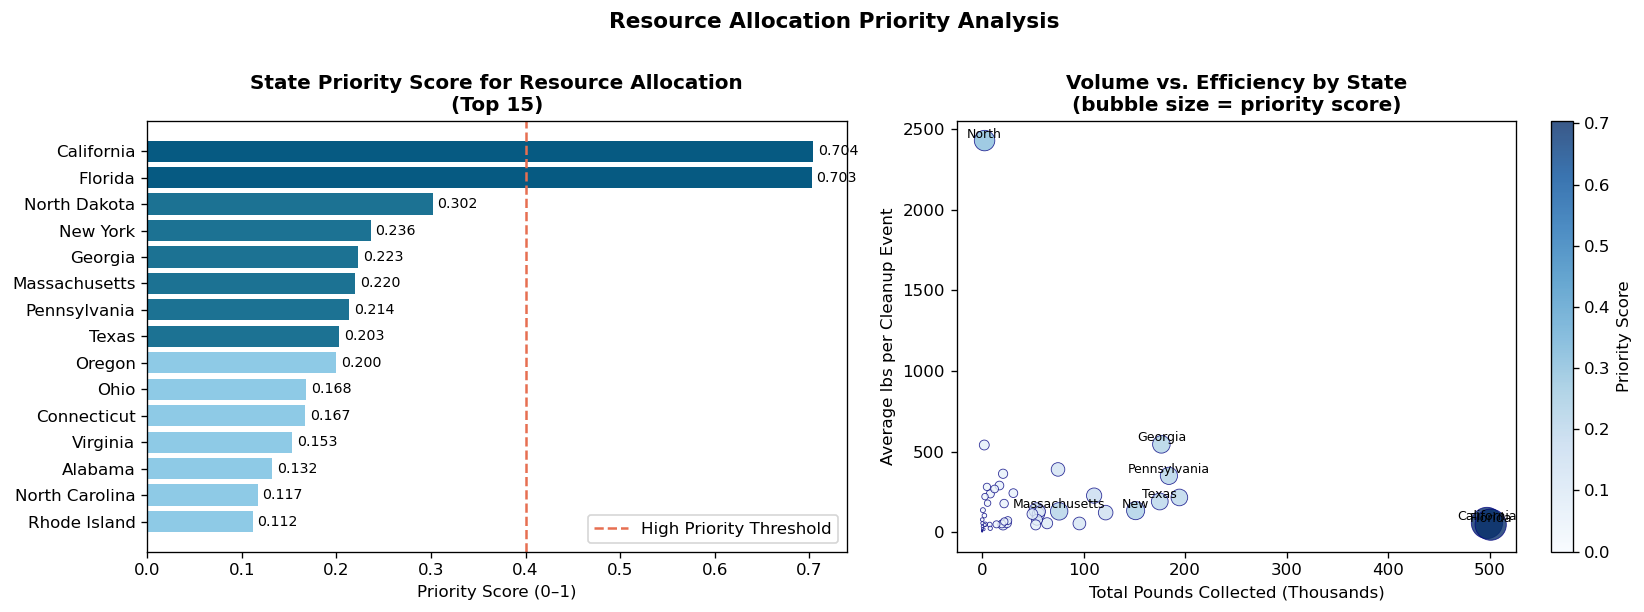

In [65]:
# Visualize Priority Scores
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart - top 15
top15 = state_summary.head(15)
bar_colors = [OCEAN_BLUE if s > 0.4 else TEAL if s > 0.2 else '#8ecae6' 
              for s in top15['Priority_Score']]
axes[0].barh(top15['State_Short'][::-1], top15['Priority_Score'][::-1], color=bar_colors[::-1])
axes[0].set_title('State Priority Score for Resource Allocation\n(Top 15)', fontweight='bold')
axes[0].set_xlabel('Priority Score (0–1)')
axes[0].axvline(0.4, color=CORAL, linestyle='--', linewidth=1.5, label='High Priority Threshold')
axes[0].legend()
for bar in axes[0].patches:
    axes[0].text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
                 f'{bar.get_width():.3f}', va='center', fontsize=8.5)

# Scatter: volume vs efficiency (bubble = priority score)
sc = axes[1].scatter(
    state_summary['total_pounds'] / 1000,
    state_summary['avg_lbs_per_cleanup'],
    s=state_summary['Priority_Score'] * 500,
    c=state_summary['Priority_Score'],
    cmap='Blues', alpha=0.8, edgecolors='navy', linewidth=0.5
)
plt.colorbar(sc, ax=axes[1], label='Priority Score')
for _, row in state_summary.head(8).iterrows():
    axes[1].annotate(row['State_Short'].split()[0],
                     (row['total_pounds']/1000, row['avg_lbs_per_cleanup']),
                     fontsize=7.5, ha='center', va='bottom')
axes[1].set_xlabel('Total Pounds Collected (Thousands)')
axes[1].set_ylabel('Average lbs per Cleanup Event')
axes[1].set_title('Volume vs. Efficiency by State\n(bubble size = priority score)', fontweight='bold')

plt.suptitle('Resource Allocation Priority Analysis', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [66]:
# ML-Based Yield Predictions for Planning
print('='*60)
print('📊 YIELD FORECASTER — Pre-Event Resource Planning Tool')
print('='*60)
print('Using Random Forest model to forecast plastic yield\n')

scenarios = pd.DataFrame([
    {'Label': 'Small event – CA coast',   'People':10,  'Miles':0.5, 'Month':9, 'State':'California',  'Single_Use_Plastic':80,   'Foam_Items':30,   'Fishing_Gear':5,   'Beverage_Items':50,   'Fragments':60},
    {'Label': 'Medium event – FL coast',  'People':50,  'Miles':1.5, 'Month':9, 'State':'Florida',     'Single_Use_Plastic':300,  'Foam_Items':120,  'Fishing_Gear':20,  'Beverage_Items':200,  'Fragments':200},
    {'Label': 'Large event – TX coast',   'People':150, 'Miles':3.0, 'Month':9, 'State':'Texas',       'Single_Use_Plastic':800,  'Foam_Items':400,  'Fishing_Gear':80,  'Beverage_Items':600,  'Fragments':500},
    {'Label': 'Mass event – NC coast',    'People':500, 'Miles':6.0, 'Month':9, 'State':'N. Carolina', 'Single_Use_Plastic':2000, 'Foam_Items':1000, 'Fishing_Gear':200, 'Beverage_Items':1500, 'Fragments':1200},
])

# Map state to encoded value (use median as approximation for unseen)
scenarios['State_enc'] = [4, 9, 43, 33]  # CA, FL, TX, NC indices
scenarios['Type_enc']  = 0  # Land cleanup

X_scenario = scenarios[FEATURES]
preds_log = rf.predict(X_scenario)
preds_lbs = np.expm1(preds_log)

print(f'{"Scenario":<35} {"Volunteers":>12} {"Predicted Yield":>16} {"lbs/person":>12}')
print('-'*77)
for i, row in scenarios.iterrows():
    lpp = preds_lbs[i] / row['People']
    print(f"{row['Label']:<35} {int(row['People']):>12,} {preds_lbs[i]:>14.1f} lbs {lpp:>10.2f}")

📊 YIELD FORECASTER — Pre-Event Resource Planning Tool
Using Random Forest model to forecast plastic yield

Scenario                              Volunteers  Predicted Yield   lbs/person
-----------------------------------------------------------------------------
Small event – CA coast                        10           46.2 lbs       4.62
Medium event – FL coast                       50          183.2 lbs       3.66
Large event – TX coast                       150          651.2 lbs       4.34
Mass event – NC coast                        500         1185.6 lbs       2.37


## 8. Key Findings & Business Recommendations

### 🔍 Findings

1. **California and Florida** are the highest-priority states for resource deployment — highest combined volume, items, and operational scale.
2. **Fall (September–October)** is the peak season with ~10× more pounds collected than Spring/Summer. Resource deployment should be front-loaded to Q3.
3. **Single-use plastic (cigarette butts, food wrappers, straws)** accounts for the largest share of items — targeting high-density urban coastal zones maximizes collection.
4. **Number of volunteers** is the #1 predictor of yield (importance=0.56). Every additional volunteer has measurable impact.
5. **Random Forest** significantly outperforms Linear Regression: R²=0.78 vs 0.27, MAE=58 lbs vs 131 lbs.

### 💡 Business Recommendations

| Priority | Action |
|----------|--------|
| 🔴 High | Deploy maximum resources to California, Florida, and Texas in September |
| 🔴 High | Use the Random Forest model to pre-screen events and estimate yield before committing logistics |
| 🟡 Medium | Partner with corporate sponsors for mass volunteer events (500+ people) — highest ROI |
| 🟡 Medium | Target single-use plastic hotspots in urban coastal zones of CA and FL |
| 🟢 Low | Expand monitoring to underrepresented inland states to complete the national picture |

In [67]:
# Export priority table for the report
export_cols = ['Rank','State_Short','total_pounds','total_items','avg_lbs_per_cleanup',
               'avg_lbs_per_person','num_events','Priority_Score']
state_summary[export_cols].head(20).to_csv('state_priority_scores.csv', index=False)
print('✅ Exported state_priority_scores.csv')
print('\n✅ Full analysis complete!')

✅ Exported state_priority_scores.csv

✅ Full analysis complete!


In [68]:
state_summary[export_cols]


,Rank,State_Short,total_pounds,total_items,avg_lbs_per_cleanup,avg_lbs_per_person,num_events,Priority_Score
0,1,California,497424.582000,3150991.0,57.519031,7.186286,8648,0.7040
1,2,Florida,501141.452000,3116795.0,47.042284,6.242749,10653,0.7025
2,3,North Dakota,2430.000000,1.0,2430.000000,10.041322,1,0.3019
3,4,New York,151293.913636,1038552.0,133.888419,7.394043,1130,0.2361
4,5,Georgia,176660.950000,152825.0,545.249846,27.226325,324,0.2228
5,6,Massachusetts,75918.670000,1502783.0,129.554044,8.757141,586,0.2196
6,7,Pennsylvania,184078.400000,249549.0,349.958935,17.698604,526,0.2138
7,8,Texas,175058.633738,420586.0,190.695679,13.562269,918,0.2032
8,9,Oregon,194376.252727,190602.0,215.733910,13.638927,901,0.1998
9,10,Ohio,110380.220000,543116.0,227.119794,19.922578,486,0.1678
